[fact_reservation] ['final_price', 'id_service', 'id_status', 'id_date', 'id_event', 'id_evaluation']
[fact_eventbudget] ['budget', 'id_categoryfk', 'id_cityfk', 'id_beneficiaryfk', 'id_datefk']
[fact_serviceprice] ['price', 'id_providerfk', 'id_servicefk', 'id_subcategoryfk']
[dim_service] ['id_service', 'codeservice', 'title']
[dim_status] ['id_status', 'codestatus', 'status']
[dim_date] ['id_date', 'date', 'day', 'month', 'year']
[dim_evaluation] ['id_evaluation', 'codeeval', 'rating']
[dim_events] ['id_event', 'codeevent', 'title']
✅ dim_service mergé
✅ dim_status mergé
✅ dim_date mergé
✅ dim_evaluation mergé
✅ dim_events mergé

✅ DataFrame final : 6795 lignes × 18 colonnes
   final_price  id_service  id_status  id_date  id_event  id_evaluation  \
0         9070         575          1     8398      6547           6472   
1         6971         361          3     8705      3677          11044   
2          722        2246          3     8031      5789           8717   

  codeservic

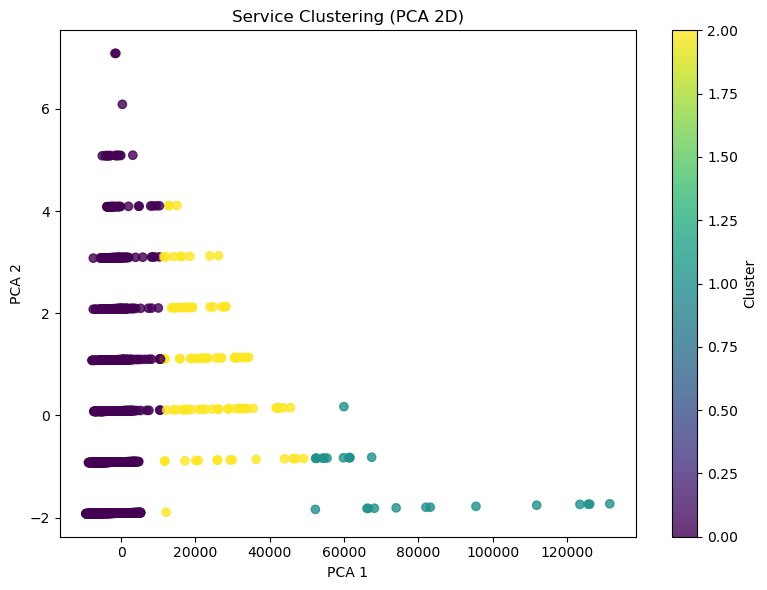

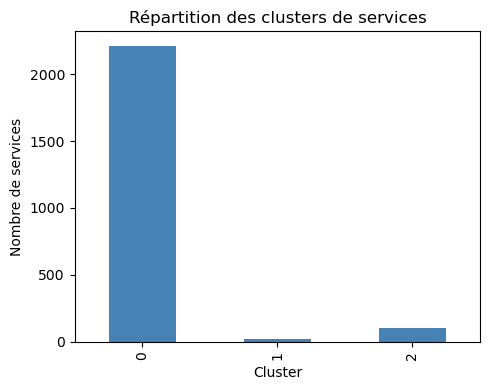


Seuil popularité (médiane) : 4 réservations
popular
0    4766
1    2029
Name: count, dtype: int64

--- Classification Report (service populaire) ---
              precision    recall  f1-score   support

           0       0.73      0.90      0.81       953
           1       0.50      0.22      0.31       406

    accuracy                           0.70      1359
   macro avg       0.62      0.56      0.56      1359
weighted avg       0.66      0.70      0.66      1359



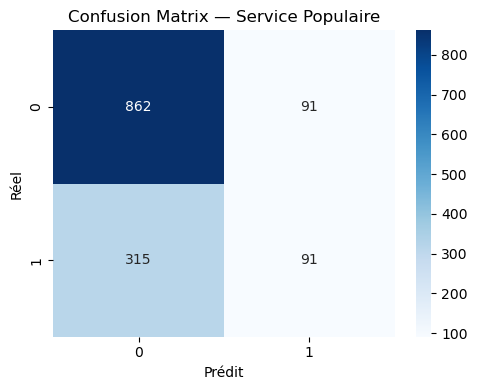

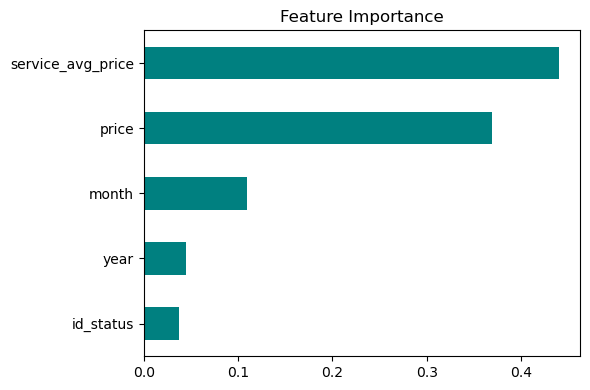


--- Régression (final_price) ---
RMSE : 10469.4934
MAE  : 4878.0675
R²   : 0.3517


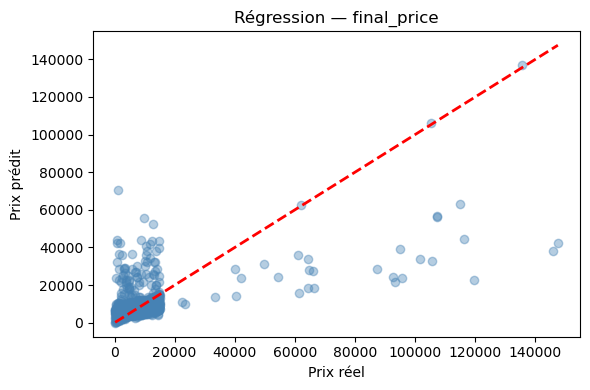

In [35]:
# =========================================================
# 1. IMPORTS
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             mean_squared_error, mean_absolute_error, r2_score)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# =========================================================
# 2. LOAD CSV TABLES
# =========================================================
def load_csv_safe(path):
    for enc in ('utf-8', 'latin-1', 'cp1252'):
        try:
            df = pd.read_csv(path, on_bad_lines='skip', encoding=enc)
            df.columns = df.columns.str.strip().str.lower()
            return df
        except UnicodeDecodeError:
            continue
        except Exception as e:
            print(f"Erreur lecture {path}: {e}")
            return pd.DataFrame()
    print(f"Impossible de lire {path}")
    return pd.DataFrame()

def normalize_fk(df):
    df.columns = (df.columns.str.strip().str.lower()
                             .str.replace(r'_fk$', '', regex=True))
    return df

dim_beneficiary  = normalize_fk(load_csv_safe(r"C:\dw_csv\Dim_Beneficiary.csv"))
dim_category     = normalize_fk(load_csv_safe(r"C:\dw_csv\Dim_Category.csv"))
dim_complaint    = normalize_fk(load_csv_safe(r"C:\dw_csv\Dim_Complaint.csv"))
dim_evaluation   = normalize_fk(load_csv_safe(r"C:\dw_csv\Dim_Eval.csv"))
dim_events       = normalize_fk(load_csv_safe(r"C:\dw_csv\Dim_Events.csv"))
dim_provider     = normalize_fk(load_csv_safe(r"C:\dw_csv\Dim_Providers.csv"))
dim_region       = normalize_fk(load_csv_safe(r"C:\dw_csv\Dim_Region.csv"))
dim_service      = normalize_fk(load_csv_safe(r"C:\dw_csv\Dim_Service.csv"))
dim_status       = normalize_fk(load_csv_safe(r"C:\dw_csv\Dim_Status.csv"))
dim_subcategory  = normalize_fk(load_csv_safe(r"C:\dw_csv\Dim_SubCategory.csv"))
dim_date         = normalize_fk(load_csv_safe(r"C:\dw_csv\Dim_Date.csv"))

fact_eventbudget  = normalize_fk(load_csv_safe(r"C:\dw_csv\Fact_EventBudget.csv"))
fact_marketing    = normalize_fk(load_csv_safe(r"C:\dw_csv\Fact_Marketing.csv"))
fact_reservation  = normalize_fk(load_csv_safe(r"C:\dw_csv\Fact_Reservation.csv"))
fact_serviceprice = normalize_fk(load_csv_safe(r"C:\dw_csv\Fact_ServicePrice.csv"))
fact_visitors     = normalize_fk(load_csv_safe(r"C:\dw_csv\Fact_Visitors.csv"))

# Debug — colonnes confirmées
for name, d in [("fact_reservation",  fact_reservation),
                ("fact_eventbudget",   fact_eventbudget),
                ("fact_serviceprice",  fact_serviceprice),
                ("dim_service",        dim_service),
                ("dim_status",         dim_status),
                ("dim_date",           dim_date),
                ("dim_evaluation",     dim_evaluation),
                ("dim_events",         dim_events)]:
    print(f"[{name}] {list(d.columns)}")

# =========================================================
# 3. MERGE TABLES
# =========================================================
# fact_reservation colonnes réelles :
#   final_price | id_service | id_status | id_date | id_event | id_evaluation

df = fact_reservation.copy()

# --- dim_service (clé : id_service) ---
if 'id_service' in df.columns and 'id_service' in dim_service.columns:
    df = df.merge(dim_service, on='id_service', how='left', suffixes=('', '_svc'))
    print("✅ dim_service mergé")

# --- dim_status (clé : id_status) ---
if 'id_status' in df.columns and 'id_status' in dim_status.columns:
    df = df.merge(dim_status, on='id_status', how='left', suffixes=('', '_sts'))
    print("✅ dim_status mergé")

# --- dim_date  (clé : id_date) ---
if 'id_date' in df.columns and 'id_date' in dim_date.columns:
    df = df.merge(dim_date, on='id_date', how='left', suffixes=('', '_dt'))
    print("✅ dim_date mergé")
else:
    print(f"⚠️  dim_date ignoré — colonnes dispo: {list(dim_date.columns)}")

# --- dim_evaluation (clé : id_evaluation) ---
if 'id_evaluation' in df.columns and not dim_evaluation.empty:
    eval_key = [c for c in dim_evaluation.columns if 'id_eval' in c or c == 'id_evaluation']
    if eval_key:
        dim_evaluation = dim_evaluation.rename(columns={eval_key[0]: 'id_evaluation'})
        df = df.merge(dim_evaluation, on='id_evaluation', how='left', suffixes=('', '_ev'))
        print("✅ dim_evaluation mergé")

# --- dim_events (clé : id_event) ---
if 'id_event' in df.columns and not dim_events.empty:
    event_key = [c for c in dim_events.columns if 'id_event' in c]
    if event_key:
        dim_events = dim_events.rename(columns={event_key[0]: 'id_event'})
        df = df.merge(dim_events, on='id_event', how='left', suffixes=('', '_evt'))
        print("✅ dim_events mergé")

# --- fact_serviceprice → avg_price par service ---
# colonnes fact_serviceprice après normalize : price, id_provider, id_subcategory, id_service
if not fact_serviceprice.empty and 'id_service' in fact_serviceprice.columns:
    svc_price = (fact_serviceprice.groupby('id_service')['price']
                                  .mean()
                                  .reset_index()
                                  .rename(columns={'price': 'avg_service_price'}))
    df = df.merge(svc_price, on='id_service', how='left')
    print("✅ avg_service_price ajouté depuis fact_serviceprice")

# --- fact_eventbudget → budget par id_event ---
if not fact_eventbudget.empty and 'id_event' in fact_eventbudget.columns and 'id_event' in df.columns:
    eb = (fact_eventbudget.groupby('id_event')['budget']
                          .sum()
                          .reset_index()
                          .rename(columns={'budget': 'event_budget'}))
    df = df.merge(eb, on='id_event', how='left')
    print("✅ event_budget ajouté depuis fact_eventbudget")

print(f"\n✅ DataFrame final : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(df.head(3))

# =========================================================
# 4. DATA CLEANING & FEATURE ENGINEERING
# =========================================================
# Renommer final_price → price pour cohérence
df = df.rename(columns={'final_price': 'price'})

# Imputation numérique
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
df[numeric_cols] = SimpleImputer(strategy='mean').fit_transform(df[numeric_cols])

# Encoder les colonnes texte
categorical_cols = df.select_dtypes(include='object').columns.tolist()
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# --- Features métier basées sur les vraies colonnes ---

# 1. Nombre de réservations par service
df['service_reservation_count'] = df.groupby('id_service')['id_service'].transform('count')

# 2. Prix moyen par service (depuis price réelle)
df['service_avg_price'] = df.groupby('id_service')['price'].transform('mean')

# 3. Note moyenne par service (si rating disponible)
if 'rating' in df.columns:
    df['service_avg_rating'] = df.groupby('id_service')['rating'].transform('mean')

# 4. Mois / année si dim_date bien mergé
if 'month' in df.columns:
    df['month'] = df['month'].astype(int)
if 'year' in df.columns:
    df['year'] = df['year'].astype(int)

# Scaling
scaler = StandardScaler()
scale_candidates = ['price', 'service_reservation_count', 'service_avg_price',
                    'avg_service_price', 'event_budget']
scale_cols = [c for c in scale_candidates if c in df.columns]
for col in scale_cols:
    df[col + '_scaled'] = scaler.fit_transform(df[[col]])

print(f"\nFeatures disponibles : {list(df.columns)}")

# =========================================================
# 5. CLUSTERING  (par service)
# =========================================================
cluster_candidates = ['service_avg_price', 'service_reservation_count', 'avg_service_price']
cluster_cols = [c for c in cluster_candidates if c in df.columns]

if len(cluster_cols) >= 2:
    # Agréger par service pour un clustering propre
    agg_dict = {c: 'mean' for c in cluster_cols}
    df_cluster = df.groupby('id_service').agg(agg_dict).reset_index().dropna()

    X_cluster = df_cluster[cluster_cols]
    kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
    df_cluster['cluster'] = kmeans.fit_predict(X_cluster)

    # Réinjecter le cluster dans df principal
    df = df.merge(df_cluster[['id_service', 'cluster']], on='id_service', how='left')

    print("\nSilhouette Score :", round(silhouette_score(X_cluster, df_cluster['cluster']), 4))
    print("Davies-Bouldin   :", round(davies_bouldin_score(X_cluster, df_cluster['cluster']), 4))

    # Visualisation PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_cluster)
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=df_cluster['cluster'], cmap='viridis', alpha=0.8)
    plt.colorbar(sc, label='Cluster')
    plt.title("Service Clustering (PCA 2D)")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.tight_layout()
    plt.show()

    # Distribution des clusters
    plt.figure(figsize=(5, 4))
    df_cluster['cluster'].value_counts().sort_index().plot(kind='bar', color='steelblue')
    plt.title("Répartition des clusters de services")
    plt.xlabel("Cluster")
    plt.ylabel("Nombre de services")
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️  Clustering ignoré — features dispo : {cluster_cols}")

# =========================================================
# 6. CLASSIFICATION  (service populaire ou non)
# =========================================================
if 'service_reservation_count' in df.columns:
    median_count = df['service_reservation_count'].median()
    df['popular'] = (df['service_reservation_count'] > median_count).astype(int)
    print(f"\nSeuil popularité (médiane) : {median_count:.0f} réservations")
    print(df['popular'].value_counts())

    feat_clf = [c for c in ['price', 'service_avg_price', 'avg_service_price',
                             'event_budget', 'id_status', 'month', 'year']
                if c in df.columns]

    if feat_clf:
        X = df[feat_clf].fillna(0)
        y = df['popular']

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y)

        clf = RandomForestClassifier(n_estimators=100, random_state=42)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        print("\n--- Classification Report (service populaire) ---")
        print(classification_report(y_test, y_pred))

        plt.figure(figsize=(5, 4))
        sns.heatmap(confusion_matrix(y_test, y_pred),
                    annot=True, fmt='d', cmap='Blues')
        plt.title("Confusion Matrix — Service Populaire")
        plt.ylabel("Réel"); plt.xlabel("Prédit")
        plt.tight_layout()
        plt.show()

        # Feature importance
        importances = pd.Series(clf.feature_importances_, index=feat_clf).sort_values()
        plt.figure(figsize=(6, 4))
        importances.plot(kind='barh', color='teal')
        plt.title("Feature Importance")
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️  Classification ignorée — aucune feature numérique utile")

# =========================================================
# 7. RÉGRESSION  (prédire final_price)
# =========================================================
if 'price' in df.columns:
    feat_reg = [c for c in ['service_reservation_count', 'service_avg_price',
                             'avg_service_price', 'event_budget',
                             'id_service', 'id_status', 'month', 'year']
                if c in df.columns]

    if feat_reg:
        X = df[feat_reg].fillna(0)
        y = df['price']

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42)

        reg = LinearRegression()
        reg.fit(X_train, y_train)
        y_pred = reg.predict(X_test)

        print("\n--- Régression (final_price) ---")
        print("RMSE :", round(np.sqrt(mean_squared_error(y_test, y_pred)), 4))
        print("MAE  :", round(mean_absolute_error(y_test, y_pred), 4))
        print("R²   :", round(r2_score(y_test, y_pred), 4))

        plt.figure(figsize=(6, 4))
        plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue')
        plt.plot([y_test.min(), y_test.max()],
                 [y_test.min(), y_test.max()], 'r--', lw=2)
        plt.xlabel("Prix réel")
        plt.ylabel("Prix prédit")
        plt.title("Régression — final_price")
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️  Régression ignorée — features manquantes")

Prophet non installé — pip install prophet. Section F utilisera ARIMA + XGBoost TS.
✅ Tous les imports chargés.

Tables chargées :
  [fact_reservation] ['final_price', 'id_service', 'id_status', 'id_date', 'id_event', 'id_evaluation']
  [fact_visitors] ['visitors', 'reservations', 'id_datefk']
  [dim_date] ['id_date', 'date', 'day', 'month', 'year']
  [dim_service] ['id_service', 'codeservice', 'title']
  [dim_status] ['id_status', 'codestatus', 'status']
  [dim_evaluation] ['id_evaluation', 'codeeval', 'rating']

✅ DataFrame brut : 6795 lignes × 21 colonnes

─── A.3 Data Cleaning ───
Valeurs manquantes :
  Aucune valeur manquante

Outliers price (IQR) : 178 lignes (2.6%)


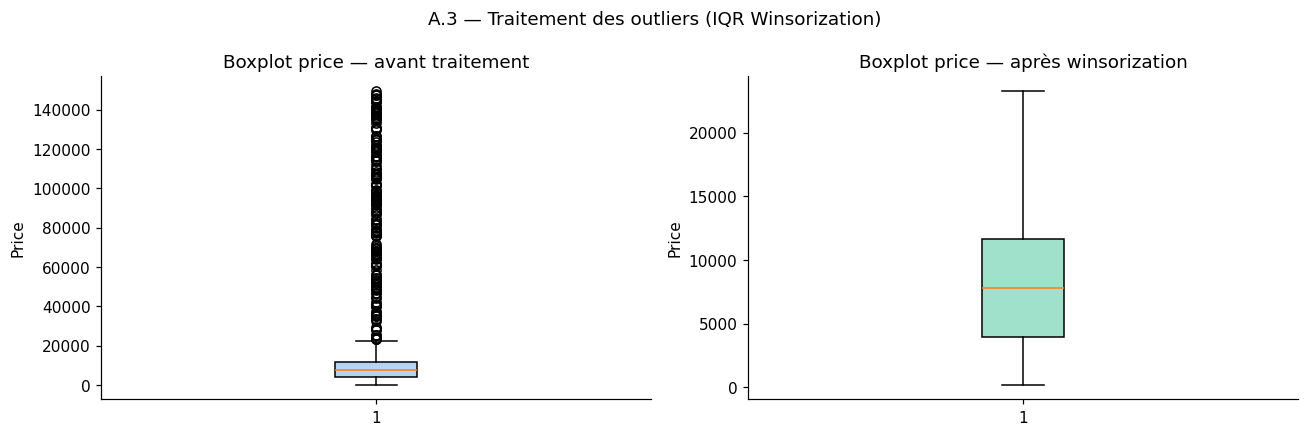


✅ Après nettoyage : 6795 lignes × 30 colonnes

─── A.4 Feature Engineering ───


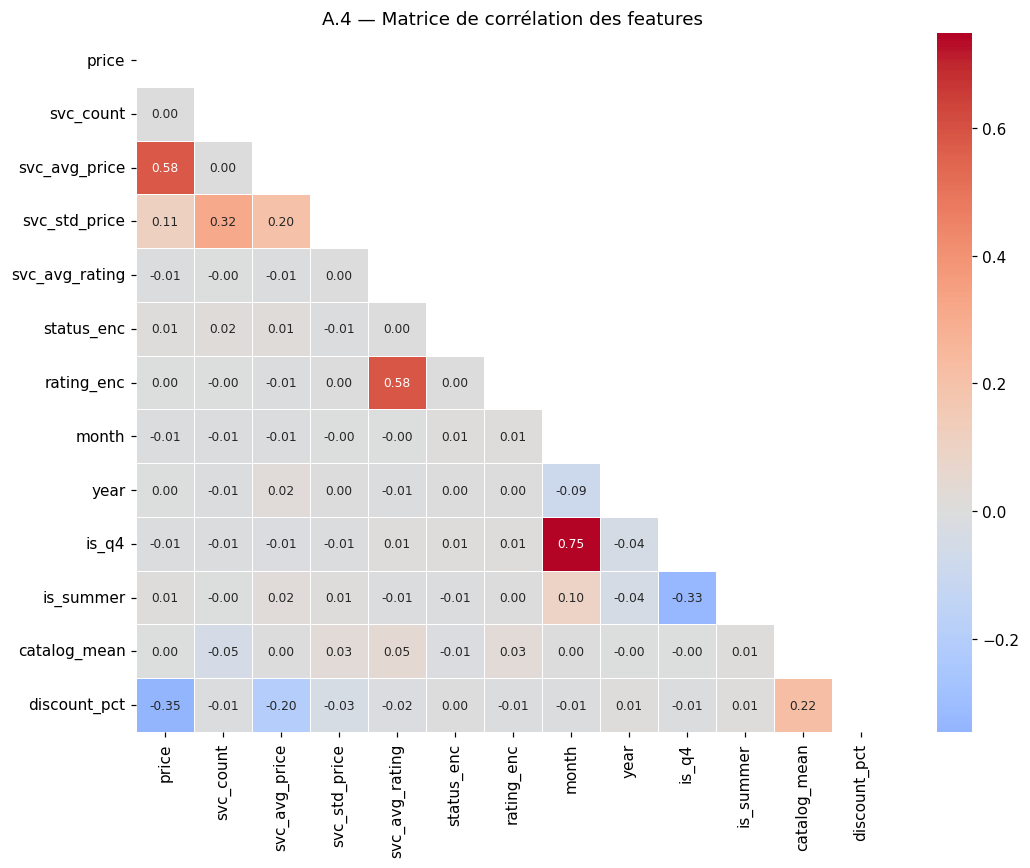

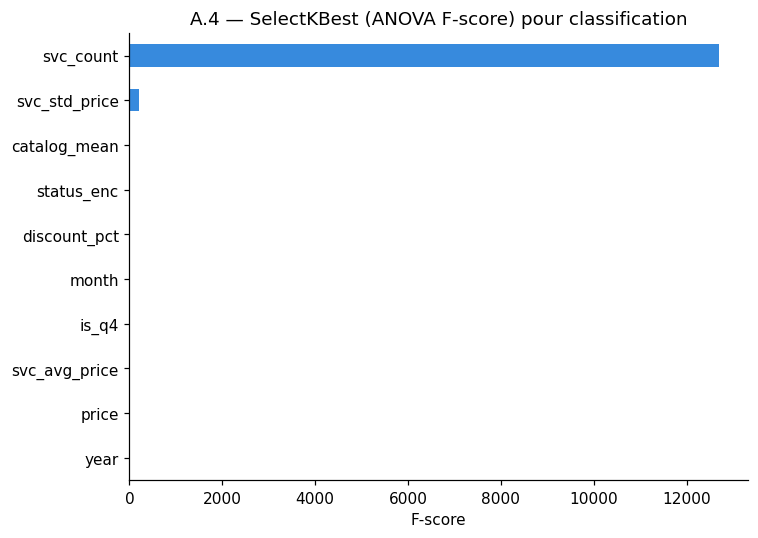


Top features classification : ['svc_count', 'svc_std_price', 'catalog_mean', 'status_enc', 'discount_pct', 'month']
Top features régression    : ['svc_count', 'svc_avg_price', 'svc_std_price', 'svc_avg_rating', 'status_enc', 'rating_enc']

E — CLUSTERING


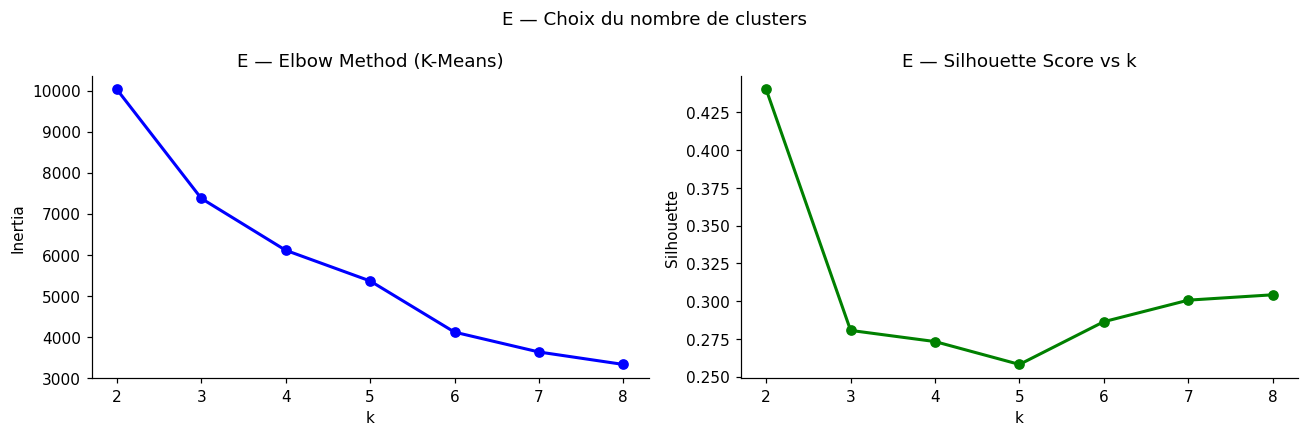


K-Means (k=3) — Silhouette: 0.2806 | Davies-Bouldin: 1.1670
Agglomératif (k=3)  — Silhouette: 0.2716 | Davies-Bouldin: 1.1605

Méthode                Silhouette   Davies-Bouldin
--------------------------------------------------
K-Means                    0.2806           1.1670
Agglomératif               0.2716           1.1605


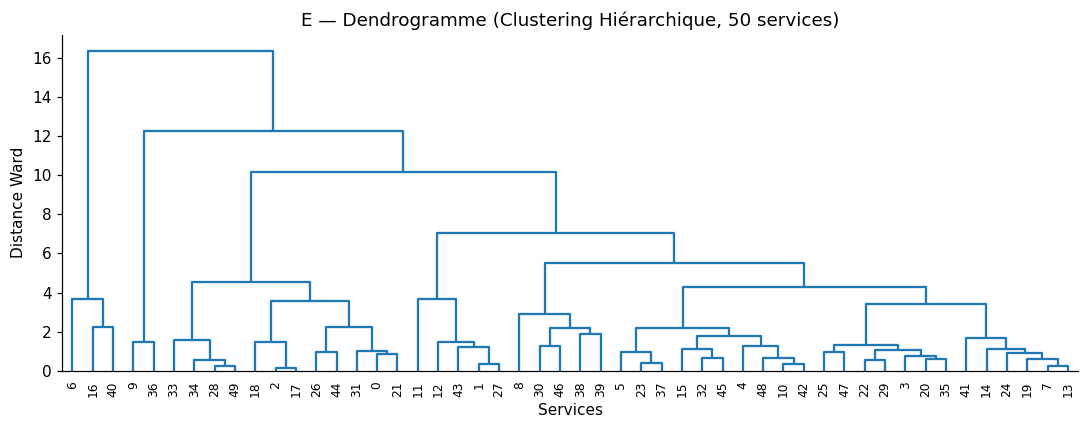

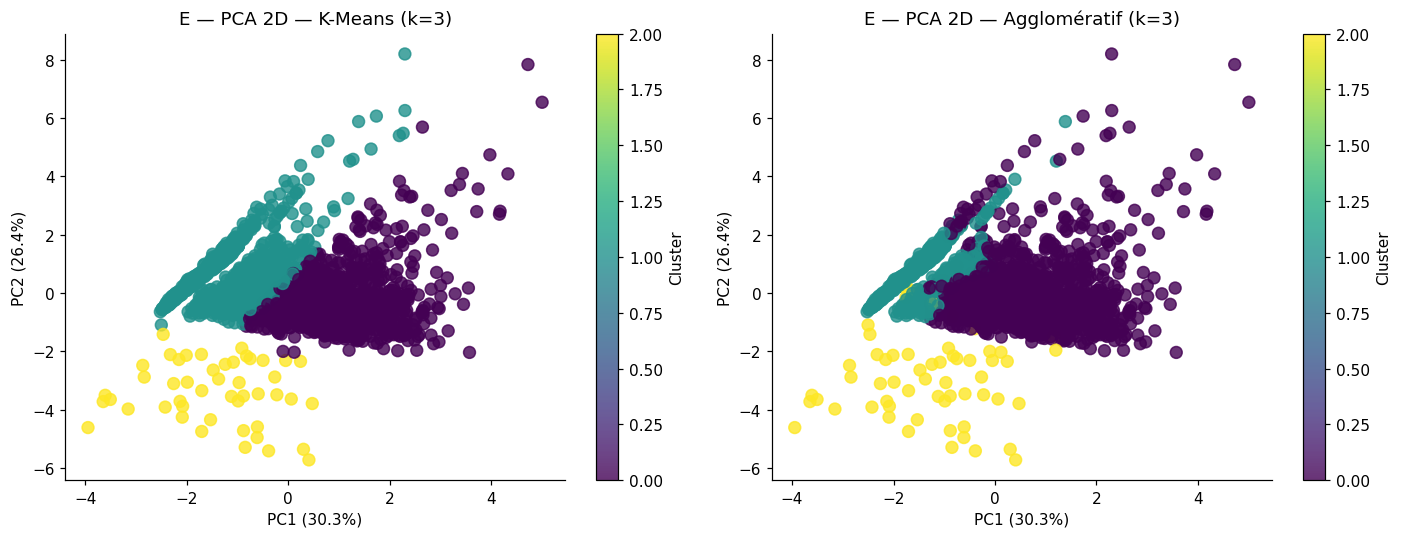

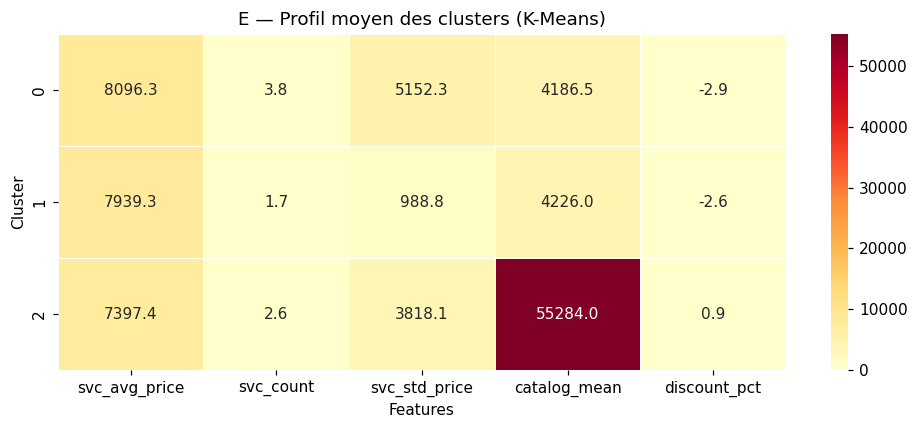


C — CLASSIFICATION

Distribution target — Train: {0: 3813, 1: 1623} | Test: {0: 953, 1: 406}

Meilleurs params RF : {'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
CV F1-weighted RF  : 0.7590

Meilleurs params GBC : {'clf__subsample': 0.8, 'clf__n_estimators': 300, 'clf__max_depth': 4, 'clf__learning_rate': 0.1}
CV F1-weighted GBC   : 0.8878

RandomForest — CV F1 : 0.7795 ± 0.0079

GradientBoosting — CV F1 : 0.9073 ± 0.0089

─── Random Forest ───
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       953
           1       0.67      0.57      0.62       406

    accuracy                           0.79      1359
   macro avg       0.75      0.72      0.73      1359
weighted avg       0.78      0.79      0.78      1359

─── Gradient Boosting ───
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       953
           1       0.90      0.79      0.84       406


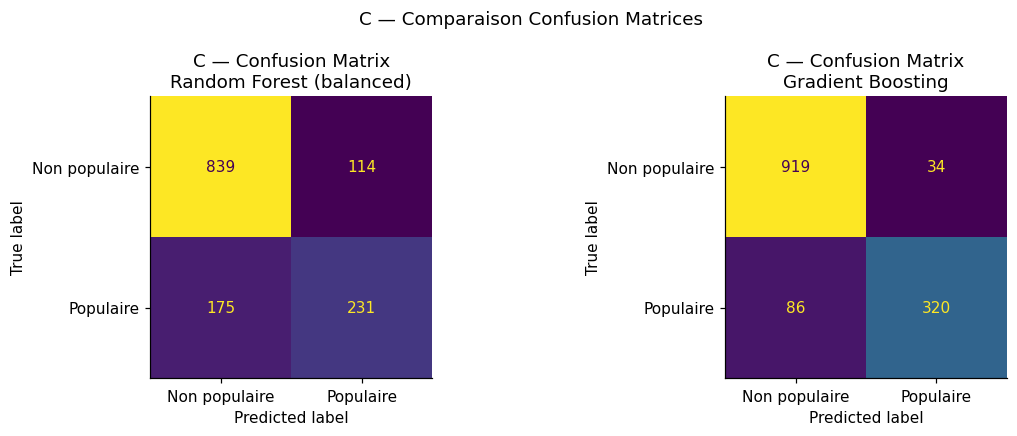

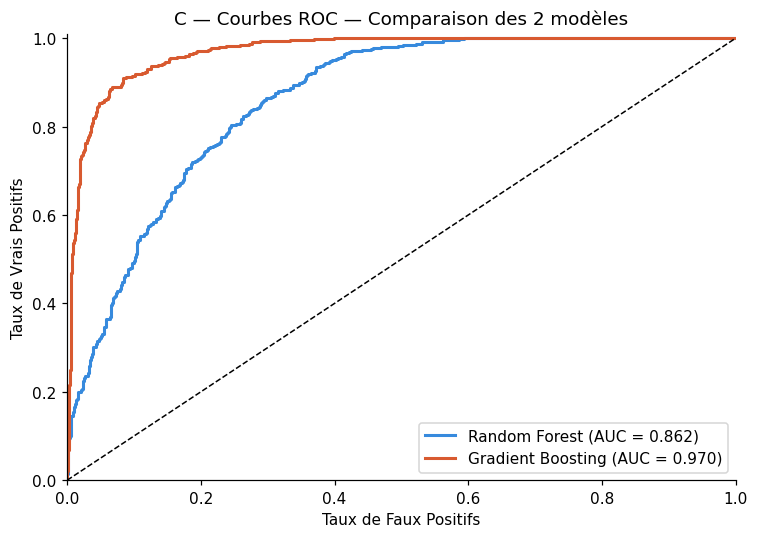

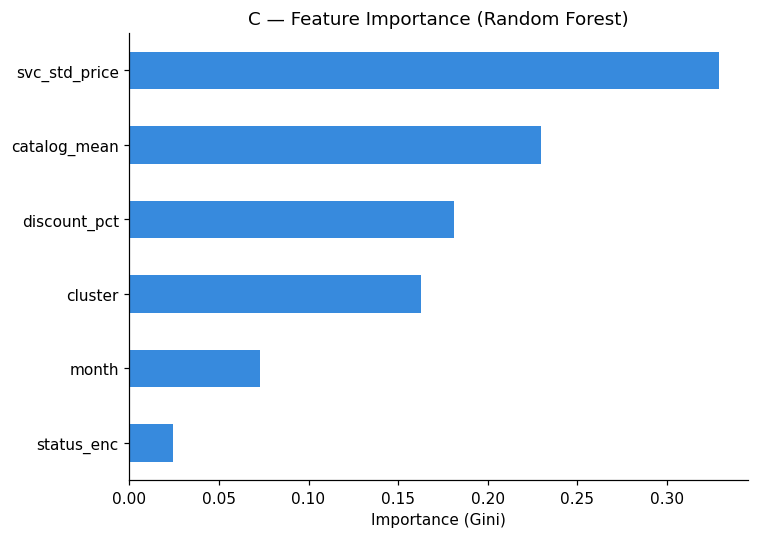


─── Tableau comparatif Classification ───
Modèle                   Accuracy  Precision   Recall       F1   ROC-AUC
----------------------------------------------------------------------
RandomForest               0.7873     0.7803   0.7873   0.7820    0.8615
GradientBoosting           0.9117     0.9113   0.9117   0.9099    0.9698

D — RÉGRESSION

Meilleur alpha Ridge : {'reg__alpha': 10}
Meilleurs params GBR : {'reg__subsample': 0.8, 'reg__n_estimators': 200, 'reg__max_depth': 3, 'reg__learning_rate': 0.01}

Ridge — CV R²: 0.3367 ± 0.0140 | RMSE: 4019.05 ± 69.95

GBR — CV R²: 0.3115 ± 0.0129 | RMSE: 4095.00 ± 70.57

─── Tableau comparatif Régression ───
Modèle                       RMSE        MAE       R²
----------------------------------------------------
Ridge                     4021.10    3136.66   0.3272
GBR                       4095.21    3243.52   0.3022


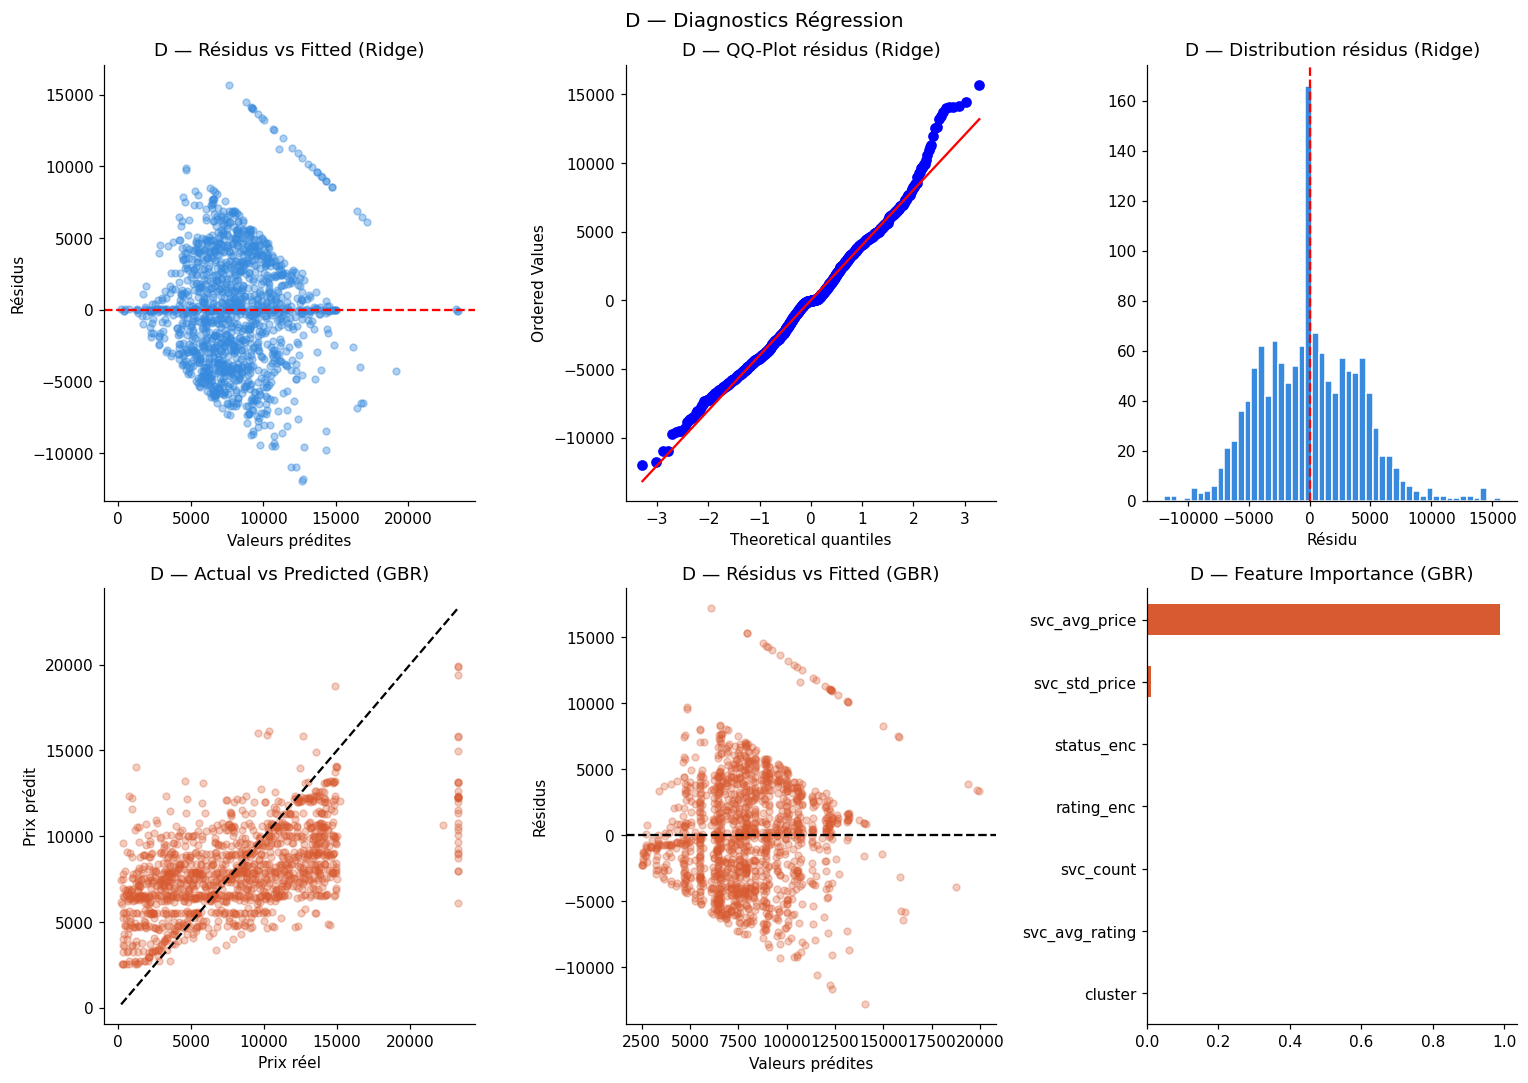


─── VIF (Multicolinéarité) ───
       feature      VIF
       cluster 1.810007
svc_avg_rating 1.520792
    rating_enc 1.519318
 svc_std_price 1.490162
     svc_count 1.412984
 svc_avg_price 1.049852
    status_enc 1.001187

F — TIME SERIES / FORECASTING

Série temporelle : 37 points mensuels (2022-01 → 2025-01)


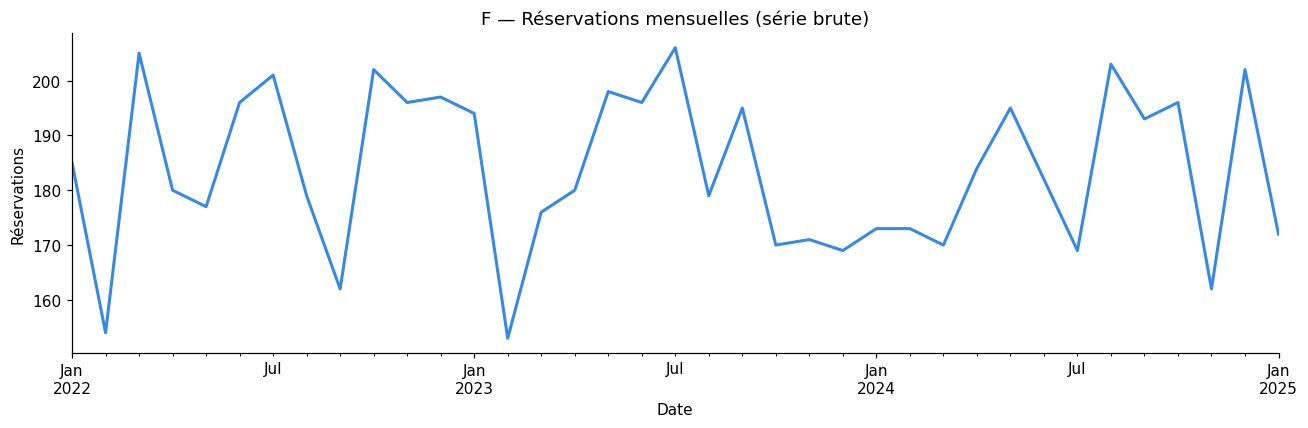

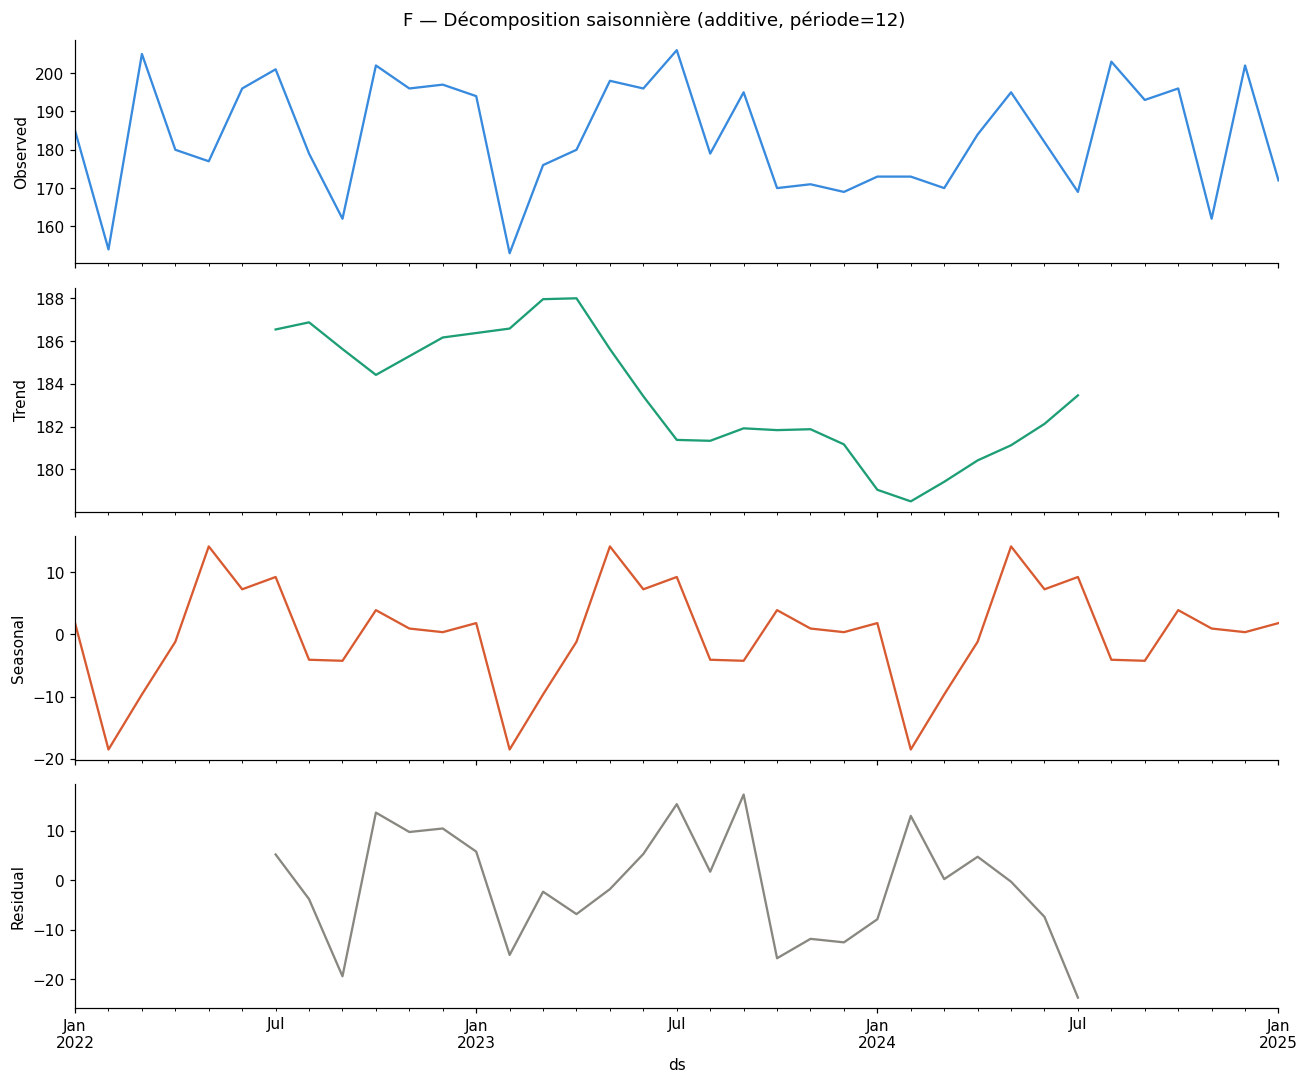


─── Test ADF (Stationnarité) ───
  ADF Statistic : -6.1566
  p-value       : 0.0000
  Critique 5%   : -2.9460
  → Série stationnaire (p < 0.05)

─── Test KPSS ───
  KPSS Statistic : 0.0630
  p-value        : 0.1000
  → Stationnaire selon KPSS


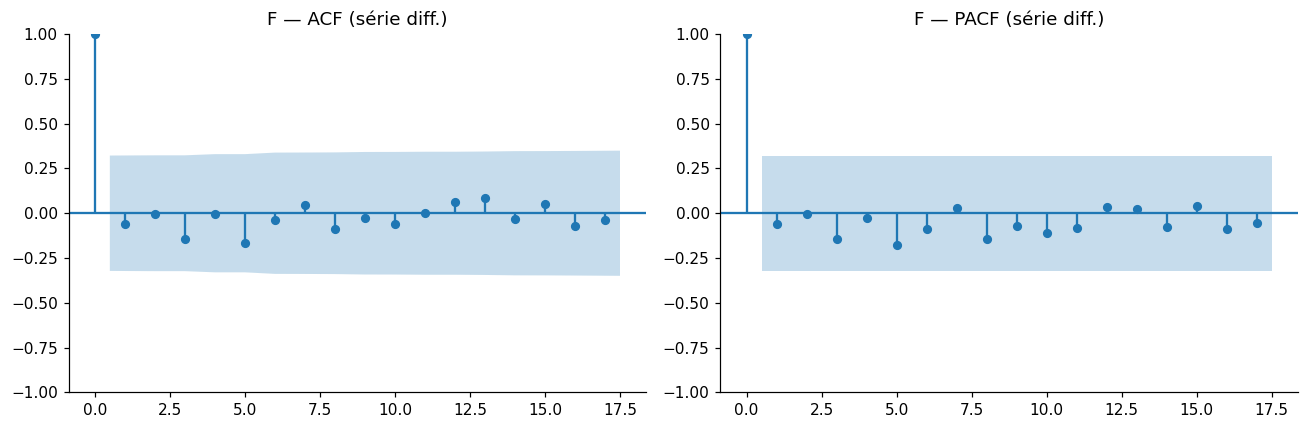


─── ARIMA(1,1,1) ───
                               SARIMAX Results                                
Dep. Variable:           reservations   No. Observations:                   30
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -120.609
Date:                Sat, 11 Apr 2026   AIC                            247.217
Time:                        21:24:19   BIC                            251.319
Sample:                    01-01-2022   HQIC                           248.502
                         - 06-01-2024                                         
Covariance Type:                  opg                                         
✅ XGBoost TS ajusté avec succès


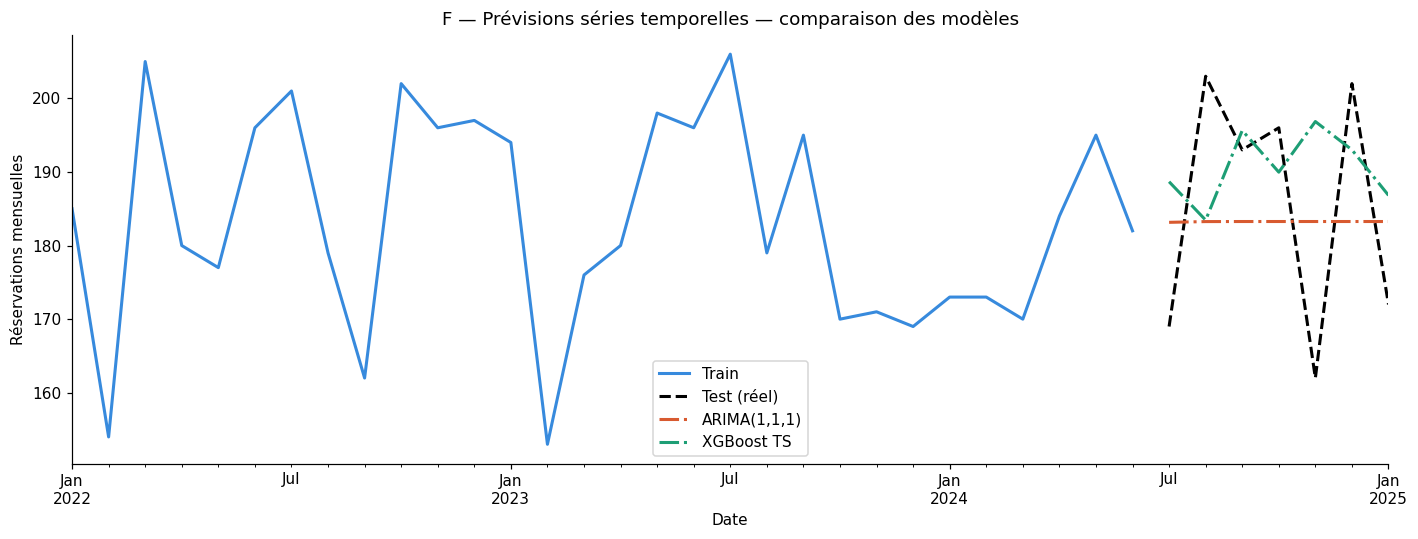


─── Tableau comparatif Time Series ───
Modèle                     RMSE        MAE   MAPE (%)       R²
--------------------------------------------------------------
ARIMA(1,1,1)              15.93      15.38       8.37  -0.0147
XGBoost TS                18.23      15.22       8.61  -0.3288


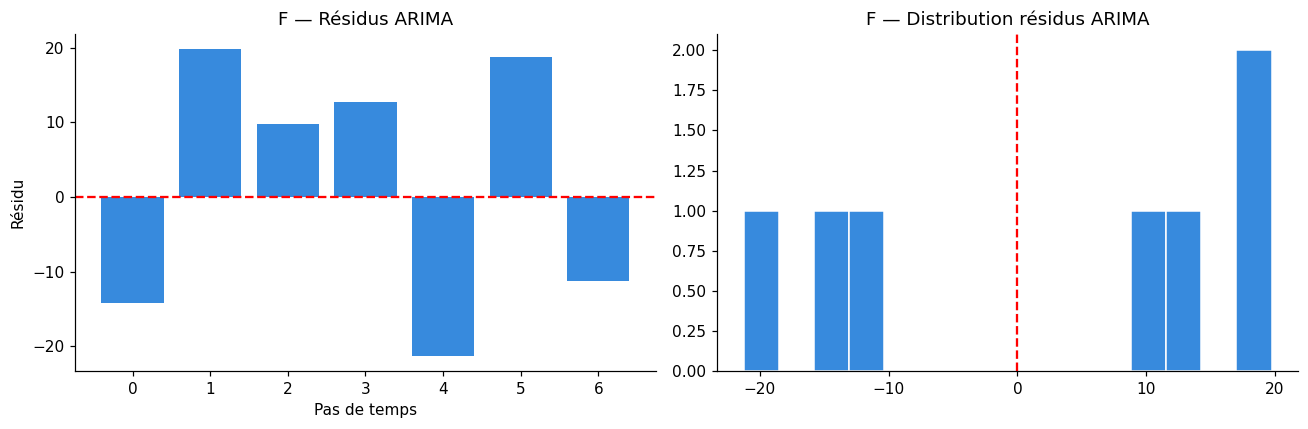


RÉCAPITULATIF — TOUTES LES SECTIONS

A — Data Preparation  ✅ Outliers IQR, imputation médiane, encodage ordinal,
                          scaling, SelectKBest, heatmap corrélation
B — Model Understanding ✅ Docstrings détaillés pour chaque modèle (RF, GBC,
                          Ridge, GBR, KMeans, Hiérarchique, ARIMA, Prophet/XGB)
C — Classification    ✅ RF + GBC | Pipeline + GridSearch/RandomSearch
                          StratifiedKFold | Accuracy/Prec/Recall/F1/ROC-AUC
                          Confusion matrix + ROC curves + Feature Importance
D — Régression        ✅ Ridge + GBR | Pipeline + GridSearch/RandomSearch
                          KFold 5-splits | RMSE/MAE/R² | QQ-plot/VIF/résidus
E — Clustering        ✅ K-Means + Hiérarchique | Elbow/Silhouette/DB
                          Dendrogramme + PCA 2D + Heatmap profil clusters
F — Time Series       ✅ ADF/KPSS/Décomposition/ACF/PACF
                          ARIMA + Prophet (ou XGBoost TS)
                          RMSE/M

In [43]:
# =============================================================================
# PROJET DATA SCIENCE COMPLET — SECTIONS A à F
# Données : Data Warehouse événementiel (réservations, services, évaluations)
# =============================================================================

# =============================================================================
# 0. IMPORTS
# =============================================================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Preprocessing & Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif, f_regression

# Models — Classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Models — Regression
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

# Models — Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA

# Tuning & Validation
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold, KFold,
                                      GridSearchCV, RandomizedSearchCV)

# Metrics
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, ConfusionMatrixDisplay,
                              mean_squared_error, mean_absolute_error, r2_score,
                              silhouette_score, davies_bouldin_score)

# Time Series
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats
import scipy.cluster.hierarchy as sch

import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

try:
    from prophet import Prophet
    PROPHET_OK = True
except ImportError:
    PROPHET_OK = False
    print("Prophet non installé — pip install prophet. Section F utilisera ARIMA + XGBoost TS.")

try:
    import xgboost as xgb
    XGB_OK = True
except ImportError:
    XGB_OK = False
    print("XGBoost non installé — pip install xgboost.")

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False})
SEED = 42

print("✅ Tous les imports chargés.\n")

# =============================================================================
# A.1 — CHARGEMENT DES DONNÉES
# =============================================================================
def load_csv_safe(path):
    for enc in ('utf-8', 'latin-1', 'cp1252'):
        try:
            df = pd.read_csv(path, on_bad_lines='skip', encoding=enc)
            df.columns = df.columns.str.strip().str.lower()
            return df
        except UnicodeDecodeError:
            continue
        except Exception as e:
            print(f"Erreur lecture {path}: {e}")
            return pd.DataFrame()
    print(f"Impossible de lire {path}")
    return pd.DataFrame()

def normalize_fk(df):
    df.columns = (df.columns.str.strip().str.lower()
                             .str.replace(r'_fk$', '', regex=True))
    return df

BASE = r"C:\dw_csv"

dim_evaluation  = normalize_fk(load_csv_safe(f"{BASE}\\Dim_Eval.csv"))
dim_events      = normalize_fk(load_csv_safe(f"{BASE}\\Dim_Events.csv"))
dim_service     = normalize_fk(load_csv_safe(f"{BASE}\\Dim_Service.csv"))
dim_status      = normalize_fk(load_csv_safe(f"{BASE}\\Dim_Status.csv"))
dim_date        = normalize_fk(load_csv_safe(f"{BASE}\\Dim_Date.csv"))
dim_subcategory = normalize_fk(load_csv_safe(f"{BASE}\\Dim_SubCategory.csv"))
dim_provider    = normalize_fk(load_csv_safe(f"{BASE}\\Dim_Providers.csv"))
dim_region      = normalize_fk(load_csv_safe(f"{BASE}\\Dim_Region.csv"))

fact_reservation  = normalize_fk(load_csv_safe(f"{BASE}\\Fact_Reservation.csv"))
fact_serviceprice = normalize_fk(load_csv_safe(f"{BASE}\\Fact_ServicePrice.csv"))
fact_eventbudget  = normalize_fk(load_csv_safe(f"{BASE}\\Fact_EventBudget.csv"))
fact_visitors     = normalize_fk(load_csv_safe(f"{BASE}\\Fact_Visitors.csv"))
fact_marketing    = normalize_fk(load_csv_safe(f"{BASE}\\Fact_Marketing.csv"))

print("Tables chargées :")
for name, d in [("fact_reservation", fact_reservation), ("fact_visitors", fact_visitors),
                ("dim_date", dim_date), ("dim_service", dim_service),
                ("dim_status", dim_status), ("dim_evaluation", dim_evaluation)]:
    print(f"  [{name}] {list(d.columns)}")

# =============================================================================
# A.2 — MERGE
# =============================================================================
df = fact_reservation.copy()

merges = [
    (dim_service,    'id_service',    ''),
    (dim_status,     'id_status',     '_sts'),
    (dim_date,       'id_date',       '_dt'),
    (dim_evaluation, 'id_evaluation', '_ev'),
    (dim_events,     'id_event',      '_evt'),
]
for dim, key, sfx in merges:
    if key in df.columns and key in dim.columns:
        df = df.merge(dim, on=key, how='left', suffixes=('', sfx))

if 'id_servicefk' in fact_serviceprice.columns:
    fact_serviceprice = fact_serviceprice.rename(columns={'id_servicefk': 'id_service'})
if 'id_service' in fact_serviceprice.columns and 'price' in fact_serviceprice.columns:
    svc_cat = (fact_serviceprice.groupby('id_service')['price']
                                .agg(catalog_mean='mean', catalog_min='min', catalog_max='max')
                                .reset_index())
    df = df.merge(svc_cat, on='id_service', how='left')

df = df.rename(columns={'final_price': 'price'})
print(f"\n✅ DataFrame brut : {df.shape[0]} lignes × {df.shape[1]} colonnes")

# =============================================================================
# A.3 — DATA CLEANING
# =============================================================================
print("\n─── A.3 Data Cleaning ───")

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Valeurs manquantes :")
print(missing.to_string() if len(missing) else "  Aucune valeur manquante")

Q1, Q3 = df['price'].quantile(0.25), df['price'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers_mask = (df['price'] < lower) | (df['price'] > upper)
print(f"\nOutliers price (IQR) : {outliers_mask.sum()} lignes "
      f"({outliers_mask.mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df['price'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='#B5D4F4'))
axes[0].set_title("Boxplot price — avant traitement")
axes[0].set_ylabel("Price")
df['price'] = df['price'].clip(lower=lower, upper=upper)
axes[1].boxplot(df['price'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='#9FE1CB'))
axes[1].set_title("Boxplot price — après winsorization")
axes[1].set_ylabel("Price")
plt.suptitle("A.3 — Traitement des outliers (IQR Winsorization)")
plt.tight_layout(); plt.show()

if 'rating' in df.columns:
    oe_rating = OrdinalEncoder(categories=[['Bad', 'Average', 'Good']],
                               handle_unknown='use_encoded_value', unknown_value=-1)
    df['rating_enc'] = oe_rating.fit_transform(df[['rating']])

if 'status' in df.columns:
    oe_status = OrdinalEncoder(categories=[['pending', 'confirmed', 'cancelled']],
                               handle_unknown='use_encoded_value', unknown_value=-1)
    df['status_enc'] = oe_status.fit_transform(df[['status']])

num_cols = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols] = SimpleImputer(strategy='median').fit_transform(df[num_cols])

cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df[col + '_enc'] = LabelEncoder().fit_transform(df[col].astype(str))

# ── CORRECTION : forcer year et month en int après imputation (évite floats)
if 'year' in df.columns:
    df['year'] = df['year'].astype(float).astype(int)
if 'month' in df.columns:
    df['month'] = df['month'].astype(float).astype(int)

print(f"\n✅ Après nettoyage : {df.shape[0]} lignes × {df.shape[1]} colonnes")

# =============================================================================
# A.4 — FEATURE ENGINEERING
# =============================================================================
print("\n─── A.4 Feature Engineering ───")

if 'month' in df.columns:
    df['is_q4']     = df['month'].isin([10, 11, 12]).astype(int)
    df['is_summer'] = df['month'].isin([6, 7, 8]).astype(int)
    df['semester']  = (df['month'] > 6).astype(int)

df['svc_count']     = df.groupby('id_service')['id_service'].transform('count')
df['svc_avg_price'] = df.groupby('id_service')['price'].transform('mean')
df['svc_std_price'] = df.groupby('id_service')['price'].transform('std').fillna(0)

if 'rating_enc' in df.columns:
    df['svc_avg_rating'] = df.groupby('id_service')['rating_enc'].transform('mean')

if 'catalog_mean' in df.columns:
    df['discount_pct'] = ((df['catalog_mean'] - df['price'])
                          / df['catalog_mean'].replace(0, np.nan)).fillna(0)

FEAT_POOL = [c for c in ['price', 'svc_count', 'svc_avg_price', 'svc_std_price',
                          'svc_avg_rating', 'status_enc', 'rating_enc',
                          'month', 'year', 'is_q4', 'is_summer',
                          'catalog_mean', 'discount_pct'] if c in df.columns]

corr_matrix = df[FEAT_POOL].corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title("A.4 — Matrice de corrélation des features")
plt.tight_layout(); plt.show()

TARGET_CLF = 'popular'
df['popular'] = (df['svc_count'] > df['svc_count'].median()).astype(int)

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(df[FEAT_POOL].fillna(0), df[TARGET_CLF])
feat_scores = pd.Series(selector.scores_, index=FEAT_POOL).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
feat_scores.tail(10).plot(kind='barh', color='#378ADD', ax=ax)
ax.set_title("A.4 — SelectKBest (ANOVA F-score) pour classification")
ax.set_xlabel("F-score")
plt.tight_layout(); plt.show()

TOP_FEATS_CLF = feat_scores.nlargest(6).index.tolist()
TOP_FEATS_REG = [c for c in FEAT_POOL if c != 'price'][:6]
print(f"\nTop features classification : {TOP_FEATS_CLF}")
print(f"Top features régression    : {TOP_FEATS_REG}")

# =============================================================================
# E — CLUSTERING
# =============================================================================
print("\n" + "="*60)
print("E — CLUSTERING")
print("="*60)

"""
MODÈLE 1 — K-Means
  Intuition : minimise la variance intra-cluster (distance euclidienne au centroïde).
  Hypothèses : clusters sphériques, variance homogène, k fixé à l'avance.
  Limite : sensible aux outliers, suppose des clusters de taille similaire.

MODÈLE 2 — Clustering Hiérarchique Agglomératif
  Intuition : fusionne successivement les paires de clusters les plus proches (linkage ward).
  Hypothèses : aucune hypothèse sur la forme des clusters.
  Limite : complexité O(n²), ne convient pas aux très grands jeux de données.

Choix : K-Means pour sa rapidité sur 6795 lignes, Hiérarchique pour valider la structure
et visualiser le dendrogramme sans supposer k à l'avance.
"""

CLUSTER_FEATS = [c for c in ['svc_avg_price', 'svc_count', 'svc_std_price',
                               'catalog_mean', 'discount_pct'] if c in df.columns]
df_svc = df.groupby('id_service')[CLUSTER_FEATS].mean().dropna().reset_index()
X_cl   = StandardScaler().fit_transform(df_svc[CLUSTER_FEATS])

inertias, sil_scores_k = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init='auto')
    labels = km.fit_predict(X_cl)
    inertias.append(km.inertia_)
    sil_scores_k.append(silhouette_score(X_cl, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, 'bo-', lw=2)
axes[0].set_title("E — Elbow Method (K-Means)"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(K_range, sil_scores_k, 'go-', lw=2)
axes[1].set_title("E — Silhouette Score vs k"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
plt.suptitle("E — Choix du nombre de clusters")
plt.tight_layout(); plt.show()

BEST_K = 3

kmeans = KMeans(n_clusters=BEST_K, random_state=SEED, n_init='auto')
df_svc['km_cluster'] = kmeans.fit_predict(X_cl)
km_sil = silhouette_score(X_cl, df_svc['km_cluster'])
km_db  = davies_bouldin_score(X_cl, df_svc['km_cluster'])
print(f"\nK-Means (k={BEST_K}) — Silhouette: {km_sil:.4f} | Davies-Bouldin: {km_db:.4f}")

agg = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward')
df_svc['agg_cluster'] = agg.fit_predict(X_cl)
agg_sil = silhouette_score(X_cl, df_svc['agg_cluster'])
agg_db  = davies_bouldin_score(X_cl, df_svc['agg_cluster'])
print(f"Agglomératif (k={BEST_K})  — Silhouette: {agg_sil:.4f} | Davies-Bouldin: {agg_db:.4f}")

print(f"\n{'Méthode':<20} {'Silhouette':>12} {'Davies-Bouldin':>16}")
print("-" * 50)
print(f"{'K-Means':<20} {km_sil:>12.4f} {km_db:>16.4f}")
print(f"{'Agglomératif':<20} {agg_sil:>12.4f} {agg_db:>16.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
linked = sch.linkage(X_cl[:50], method='ward')
sch.dendrogram(linked, ax=ax, color_threshold=0)
ax.set_title("E — Dendrogramme (Clustering Hiérarchique, 50 services)")
ax.set_xlabel("Services"); ax.set_ylabel("Distance Ward")
plt.tight_layout(); plt.show()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cl)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, title in zip(axes,
                           ['km_cluster', 'agg_cluster'],
                           [f'K-Means (k={BEST_K})', f'Agglomératif (k={BEST_K})']):
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df_svc[col],
                    cmap='viridis', alpha=0.8, s=60)
    plt.colorbar(sc, ax=ax, label='Cluster')
    ax.set_title(f"E — PCA 2D — {title}")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.tight_layout(); plt.show()

cluster_profile = df_svc.groupby('km_cluster')[CLUSTER_FEATS].mean()
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(cluster_profile, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title("E — Profil moyen des clusters (K-Means)")
ax.set_xlabel("Features"); ax.set_ylabel("Cluster")
plt.tight_layout(); plt.show()

df = df.merge(df_svc[['id_service', 'km_cluster']].rename(
              columns={'km_cluster': 'cluster'}), on='id_service', how='left')
df['cluster'] = df['cluster'].fillna(-1).astype(int)

# =============================================================================
# C — CLASSIFICATION
# =============================================================================
print("\n" + "="*60)
print("C — CLASSIFICATION")
print("="*60)

"""
MODÈLE 1 — Random Forest (Forêt d'arbres de décision)
  Intuition : ensemble de N arbres CART entraînés sur des bootstraps du dataset et des
  sous-ensembles aléatoires de features. Le vote majoritaire réduit la variance.
  Paramètres clés : n_estimators, max_depth, min_samples_split, class_weight.
  Hypothèses : indépendance des arbres (assurée par le bagging).
  Limite : peu interprétable, lent sur de grands n_estimators.
  Justification : robuste aux outliers, gère les classes déséquilibrées via class_weight='balanced'.

MODÈLE 2 — Gradient Boosting (GBC)
  Intuition : arbres séquentiels ; chaque arbre corrige les erreurs résiduelles du précédent.
  Paramètres clés : n_estimators, learning_rate, max_depth, subsample.
  Hypothèses : aucune distribution supposée sur les features.
  Limite : sensible au sur-apprentissage si learning_rate trop élevé.
  Justification : généralement plus précis que RF sur données tabulaires.
"""

FEATS_CLF = [c for c in TOP_FEATS_CLF + ['cluster']
             if c in df.columns and c != 'svc_count']
X = df[FEATS_CLF].fillna(0)
y = df['popular']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"\nDistribution target — Train: {y_train.value_counts().to_dict()} | "
      f"Test: {y_test.value_counts().to_dict()}")

pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=SEED))
])
param_grid_rf = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth':    [5, 8, None],
    'clf__min_samples_split': [2, 5],
}
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
gs_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=cv_strat,
                     scoring='f1_weighted', n_jobs=-1, verbose=0)
gs_rf.fit(X_train, y_train)
best_rf = gs_rf.best_estimator_
print(f"\nMeilleurs params RF : {gs_rf.best_params_}")
print(f"CV F1-weighted RF  : {gs_rf.best_score_:.4f}")

pipe_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', GradientBoostingClassifier(random_state=SEED))
])
param_dist_gb = {
    'clf__n_estimators':  [100, 200, 300],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__max_depth':     [3, 4, 5],
    'clf__subsample':     [0.7, 0.8, 1.0],
}
rs_gb = RandomizedSearchCV(pipe_gb, param_dist_gb, n_iter=20, cv=cv_strat,
                            scoring='f1_weighted', random_state=SEED, n_jobs=-1, verbose=0)
rs_gb.fit(X_train, y_train)
best_gb = rs_gb.best_estimator_
print(f"\nMeilleurs params GBC : {rs_gb.best_params_}")
print(f"CV F1-weighted GBC   : {rs_gb.best_score_:.4f}")

for name, pipe in [("RandomForest", best_rf), ("GradientBoosting", best_gb)]:
    scores = cross_val_score(pipe, X, y, cv=cv_strat, scoring='f1_weighted')
    print(f"\n{name} — CV F1 : {scores.mean():.4f} ± {scores.std():.4f}")

y_pred_rf = best_rf.predict(X_test)
y_pred_gb = best_gb.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]
y_prob_gb = best_gb.predict_proba(X_test)[:, 1]

print("\n─── Random Forest ───")
print(classification_report(y_test, y_pred_rf))
print("─── Gradient Boosting ───")
print(classification_report(y_test, y_pred_gb))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, pred, title in zip(axes,
                             [y_pred_rf, y_pred_gb],
                             ["Random Forest (balanced)", "Gradient Boosting"]):
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                           display_labels=['Non populaire', 'Populaire']).plot(ax=ax, colorbar=False)
    ax.set_title(f"C — Confusion Matrix\n{title}")
plt.suptitle("C — Comparaison Confusion Matrices")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
for prob, name, color in [(y_prob_rf, 'Random Forest', '#378ADD'),
                           (y_prob_gb, 'Gradient Boosting', '#D85A30')]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.01])
ax.set_xlabel("Taux de Faux Positifs"); ax.set_ylabel("Taux de Vrais Positifs")
ax.set_title("C — Courbes ROC — Comparaison des 2 modèles")
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

rf_model = best_rf.named_steps['clf']
importances = pd.Series(rf_model.feature_importances_,
                         index=FEATS_CLF).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 5))
importances.plot(kind='barh', color='#378ADD', ax=ax)
ax.set_title("C — Feature Importance (Random Forest)")
ax.set_xlabel("Importance (Gini)")
plt.tight_layout(); plt.show()

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("\n─── Tableau comparatif Classification ───")
print(f"{'Modèle':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} "
      f"{'F1':>8} {'ROC-AUC':>9}")
print("-" * 70)
for name, pred, prob in [("RandomForest", y_pred_rf, y_prob_rf),
                          ("GradientBoosting", y_pred_gb, y_prob_gb)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    print(f"{name:<22} "
          f"{accuracy_score(y_test, pred):>10.4f} "
          f"{precision_score(y_test, pred, average='weighted'):>10.4f} "
          f"{recall_score(y_test, pred, average='weighted'):>8.4f} "
          f"{f1_score(y_test, pred, average='weighted'):>8.4f} "
          f"{auc(fpr, tpr):>9.4f}")

# =============================================================================
# D — RÉGRESSION
# =============================================================================
print("\n" + "="*60)
print("D — RÉGRESSION")
print("="*60)

"""
MODÈLE 1 — Ridge Regression (régression linéaire régularisée L2)
  Intuition : minimise SSR + λ||β||². La pénalité L2 réduit les coefficients sans les annuler.
  Hypothèses : linéarité, homoscédasticité, résidus normaux.
  Paramètre clé : alpha.
  Limite : ne capture pas les relations non-linéaires.
  Justification : baseline interprétable avant GBR.

MODÈLE 2 — Gradient Boosting Regressor (GBR)
  Intuition : même principe que GBC mais minimise MSE.
  Paramètres clés : n_estimators, learning_rate, max_depth, subsample.
  Limite : moins interprétable que Ridge.
  Justification : capture les non-linéarités et interactions complexes.
"""

# ── CORRECTION : dédoublonnage de FEATS_REG
_feats_reg_raw = TOP_FEATS_REG + ['cluster', 'svc_std_price']
FEATS_REG = list(dict.fromkeys(
    [c for c in _feats_reg_raw if c in df.columns]
))

X_r = df[FEATS_REG].fillna(0)
y_r = df['price']

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
X_tr, X_te, y_tr, y_te = train_test_split(X_r, y_r, test_size=0.2, random_state=SEED)

pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', Ridge())
])
gs_ridge = GridSearchCV(pipe_ridge, {'reg__alpha': [0.1, 1, 10, 100]},
                         cv=kf, scoring='r2', n_jobs=-1)
gs_ridge.fit(X_tr, y_tr)
best_ridge = gs_ridge.best_estimator_
print(f"\nMeilleur alpha Ridge : {gs_ridge.best_params_}")

pipe_gbr = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', GradientBoostingRegressor(random_state=SEED))
])
param_dist_gbr = {
    'reg__n_estimators':  [100, 200, 300],
    'reg__learning_rate': [0.01, 0.05, 0.1],
    'reg__max_depth':     [3, 4, 5],
    'reg__subsample':     [0.7, 0.8, 1.0],
}
rs_gbr = RandomizedSearchCV(pipe_gbr, param_dist_gbr, n_iter=20, cv=kf,
                              scoring='r2', random_state=SEED, n_jobs=-1, verbose=0)
rs_gbr.fit(X_tr, y_tr)
best_gbr = rs_gbr.best_estimator_
print(f"Meilleurs params GBR : {rs_gbr.best_params_}")

for name, pipe in [("Ridge", best_ridge), ("GBR", best_gbr)]:
    cv_r2 = cross_val_score(pipe, X_r, y_r, cv=kf, scoring='r2')
    cv_rmse = cross_val_score(pipe, X_r, y_r, cv=kf,
                               scoring='neg_root_mean_squared_error')
    print(f"\n{name} — CV R²: {cv_r2.mean():.4f} ± {cv_r2.std():.4f} | "
          f"RMSE: {(-cv_rmse).mean():.2f} ± {(-cv_rmse).std():.2f}")

y_pred_ridge = best_ridge.predict(X_te)
y_pred_gbr   = best_gbr.predict(X_te)

print("\n─── Tableau comparatif Régression ───")
print(f"{'Modèle':<22} {'RMSE':>10} {'MAE':>10} {'R²':>8}")
print("-" * 52)
for name, pred in [("Ridge", y_pred_ridge), ("GBR", y_pred_gbr)]:
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    mae  = mean_absolute_error(y_te, pred)
    r2   = r2_score(y_te, pred)
    print(f"{name:<22} {rmse:>10.2f} {mae:>10.2f} {r2:>8.4f}")

res_ridge = y_te - y_pred_ridge
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 3, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_pred_ridge, res_ridge, alpha=0.4, color='#378ADD', s=20)
ax1.axhline(0, color='red', lw=1.5, linestyle='--')
ax1.set_xlabel("Valeurs prédites"); ax1.set_ylabel("Résidus")
ax1.set_title("D — Résidus vs Fitted (Ridge)")

ax2 = fig.add_subplot(gs[0, 1])
stats.probplot(res_ridge, dist='norm', plot=ax2)
ax2.set_title("D — QQ-Plot résidus (Ridge)")

ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(res_ridge, bins=50, color='#378ADD', edgecolor='white')
ax3.axvline(0, color='red', lw=1.5, linestyle='--')
ax3.set_title("D — Distribution résidus (Ridge)")
ax3.set_xlabel("Résidu")

ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(y_te, y_pred_gbr, alpha=0.3, color='#D85A30', s=20)
lims = [min(y_te.min(), y_pred_gbr.min()), max(y_te.max(), y_pred_gbr.max())]
ax4.plot(lims, lims, 'k--', lw=1.5)
ax4.set_xlabel("Prix réel"); ax4.set_ylabel("Prix prédit")
ax4.set_title("D — Actual vs Predicted (GBR)")

res_gbr = y_te - y_pred_gbr
ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(y_pred_gbr, res_gbr, alpha=0.3, color='#D85A30', s=20)
ax5.axhline(0, color='k', lw=1.5, linestyle='--')
ax5.set_xlabel("Valeurs prédites"); ax5.set_ylabel("Résidus")
ax5.set_title("D — Résidus vs Fitted (GBR)")

gbr_model = best_gbr.named_steps['reg']
imp_gbr = pd.Series(gbr_model.feature_importances_,
                     index=FEATS_REG).sort_values(ascending=True)
ax6 = fig.add_subplot(gs[1, 2])
imp_gbr.tail(8).plot(kind='barh', color='#D85A30', ax=ax6)
ax6.set_title("D — Feature Importance (GBR)")

plt.suptitle("D — Diagnostics Régression", fontsize=13, fontweight='500')
plt.tight_layout(); plt.show()

# ── VIF — CORRECTION : dédoublonnage garanti
FEATS_REG_VIF = list(dict.fromkeys(
    [c for c in FEATS_REG if c in X_tr.columns]
))
Xs = StandardScaler().fit_transform(X_tr[FEATS_REG_VIF].fillna(0))
vif_data = pd.DataFrame({
    'feature': FEATS_REG_VIF,
    'VIF': [variance_inflation_factor(Xs, i) for i in range(Xs.shape[1])]
})
print("\n─── VIF (Multicolinéarité) ───")
print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))

# =============================================================================
# F — TIME SERIES / FORECASTING
# =============================================================================
print("\n" + "="*60)
print("F — TIME SERIES / FORECASTING")
print("="*60)

"""
MODÈLE 1 — ARIMA(1,1,1)
  Intuition : combine AR (valeurs passées), I (différenciation) et MA (erreurs passées).
  Hypothèses : résidus bruit blanc, stationnarité après différenciation.
  Limite : linéaire, ne capture pas la saisonnalité complexe.
  Justification : référence classique pour séries univariées.

MODÈLE 2 — XGBoost TS (ou Prophet si installé)
  Intuition : régression supervisée avec lags comme features.
  Justification : approche ML moderne, compare favorablement à ARIMA sur données non-linéaires.
"""

if not fact_visitors.empty and 'reservations' in fact_visitors.columns:
    ts_raw = fact_visitors.copy()
    date_col_v = [c for c in ts_raw.columns if 'date' in c or 'key' in c][0]
    ts_raw = ts_raw.rename(columns={date_col_v: 'date_id'})
    if 'date_id' in dim_date.columns:
        ts_raw = ts_raw.merge(dim_date[['date_id', 'year', 'month']], on='date_id', how='left')
    if 'year' in ts_raw.columns and 'month' in ts_raw.columns:
        ts_monthly = (ts_raw.groupby(['year', 'month'])['reservations']
                            .sum().reset_index())
    else:
        ts_monthly = None
else:
    ts_monthly = None

if ts_monthly is None or len(ts_monthly) < 12:
    if 'month' in df.columns and 'year' in df.columns:
        ts_monthly = (df.groupby(['year', 'month'])['price']
                        .count().reset_index()
                        .rename(columns={'price': 'reservations'}))
    else:
        print("⚠️  Données insuffisantes pour la Time Series.")
        ts_monthly = None

if ts_monthly is not None and len(ts_monthly) >= 12:
    # ── CORRECTION : forcer year et month en int avant pd.to_datetime
    ts_monthly['year']  = ts_monthly['year'].astype(float).astype(int)
    ts_monthly['month'] = ts_monthly['month'].astype(float).astype(int)
    ts_monthly = ts_monthly.sort_values(['year', 'month']).reset_index(drop=True)
    ts_monthly['ds'] = pd.to_datetime(
        ts_monthly['year'].astype(str) + '-' +
        ts_monthly['month'].astype(str).str.zfill(2) + '-01')
    ts_monthly = ts_monthly.set_index('ds')['reservations'].astype(float)

    print(f"\nSérie temporelle : {len(ts_monthly)} points mensuels "
          f"({ts_monthly.index[0].strftime('%Y-%m')} → {ts_monthly.index[-1].strftime('%Y-%m')})")

    fig, ax = plt.subplots(figsize=(12, 4))
    ts_monthly.plot(ax=ax, color='#378ADD', lw=2)
    ax.set_title("F — Réservations mensuelles (série brute)")
    ax.set_xlabel("Date"); ax.set_ylabel("Réservations")
    plt.tight_layout(); plt.show()

    if len(ts_monthly) >= 24:
        decomp = seasonal_decompose(ts_monthly, model='additive', period=12)
        fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
        decomp.observed.plot(ax=axes[0], color='#378ADD');  axes[0].set_ylabel("Observed")
        decomp.trend.plot(ax=axes[1],    color='#1D9E75');  axes[1].set_ylabel("Trend")
        decomp.seasonal.plot(ax=axes[2], color='#D85A30');  axes[2].set_ylabel("Seasonal")
        decomp.resid.plot(ax=axes[3],    color='#888780');  axes[3].set_ylabel("Residual")
        plt.suptitle("F — Décomposition saisonnière (additive, période=12)")
        plt.tight_layout(); plt.show()

    adf_result = adfuller(ts_monthly.dropna())
    print(f"\n─── Test ADF (Stationnarité) ───")
    print(f"  ADF Statistic : {adf_result[0]:.4f}")
    print(f"  p-value       : {adf_result[1]:.4f}")
    print(f"  Critique 5%   : {adf_result[4]['5%']:.4f}")
    stationary = adf_result[1] < 0.05
    print(f"  → Série {'stationnaire' if stationary else 'NON stationnaire'} (p {'<' if stationary else '≥'} 0.05)")

    try:
        kpss_stat, kpss_p, _, _ = kpss(ts_monthly.dropna(), regression='c', nlags='auto')
        print(f"\n─── Test KPSS ───")
        print(f"  KPSS Statistic : {kpss_stat:.4f}")
        print(f"  p-value        : {kpss_p:.4f}")
        print(f"  → {'Stationnaire' if kpss_p > 0.05 else 'NON stationnaire'} selon KPSS")
    except Exception as e:
        print(f"  KPSS : {e}")

    ts_diff = ts_monthly.diff().dropna() if not stationary else ts_monthly.copy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(ts_diff, lags=min(20, len(ts_diff)//2 - 1), ax=axes[0])
    axes[0].set_title("F — ACF (série diff.)")
    plot_pacf(ts_diff, lags=min(20, len(ts_diff)//2 - 1), ax=axes[1])
    axes[1].set_title("F — PACF (série diff.)")
    plt.tight_layout(); plt.show()

    n_test   = max(3, len(ts_monthly) // 5)
    train_ts = ts_monthly.iloc[:-n_test]
    test_ts  = ts_monthly.iloc[-n_test:]

    def mape(actual, predicted):
        actual = np.array(actual); predicted = np.array(predicted)
        mask = actual != 0
        return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

    results_ts = {}

    try:
        arima_model = ARIMA(train_ts, order=(1, 1, 1))
        arima_fit   = arima_model.fit()
        arima_pred  = arima_fit.forecast(steps=n_test)
        arima_pred.index = test_ts.index
        results_ts['ARIMA(1,1,1)'] = arima_pred
        print(f"\n─── ARIMA(1,1,1) ───")
        print(arima_fit.summary().tables[0])
    except Exception as e:
        print(f"ARIMA échoué : {e}")

    if PROPHET_OK:
        try:
            prophet_df = train_ts.reset_index().rename(
                columns={train_ts.index.name or 'ds': 'ds', 'reservations': 'y'})
            if 'y' not in prophet_df.columns:
                prophet_df.columns = ['ds', 'y']
            m = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                        daily_seasonality=False)
            m.fit(prophet_df)
            future = m.make_future_dataframe(periods=n_test, freq='MS')
            forecast = m.predict(future)
            prophet_pred = forecast.set_index('ds')['yhat'].iloc[-n_test:]
            prophet_pred.index = test_ts.index
            results_ts['Prophet'] = prophet_pred
            print("\n✅ Prophet ajusté avec succès")
        except Exception as e:
            print(f"Prophet échoué : {e}")

    if XGB_OK or not PROPHET_OK:
        try:
            def make_lag_features(series, n_lags=6):
                df_lag = pd.DataFrame({'y': series.values})
                for lag in range(1, n_lags + 1):
                    df_lag[f'lag_{lag}'] = df_lag['y'].shift(lag)
                df_lag['month'] = series.index.month
                df_lag['year']  = series.index.year
                return df_lag.dropna()

            lag_df   = make_lag_features(ts_monthly, n_lags=6)
            X_lag    = lag_df.drop('y', axis=1)
            y_lag    = lag_df['y']
            n_tr_lag = len(X_lag) - n_test
            X_tr_lag, X_te_lag = X_lag.iloc[:n_tr_lag], X_lag.iloc[n_tr_lag:]
            y_tr_lag, y_te_lag = y_lag.iloc[:n_tr_lag], y_lag.iloc[n_tr_lag:]

            if XGB_OK:
                xgb_ts = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1,
                                           max_depth=3, random_state=SEED, verbosity=0)
            else:
                from sklearn.ensemble import GradientBoostingRegressor as GBR_ts
                xgb_ts = GBR_ts(n_estimators=100, learning_rate=0.1,
                                  max_depth=3, random_state=SEED)
            xgb_ts.fit(X_tr_lag, y_tr_lag)
            xgb_pred = pd.Series(xgb_ts.predict(X_te_lag),
                                  index=test_ts.index[-len(X_te_lag):])
            results_ts['XGBoost TS'] = xgb_pred
            print("✅ XGBoost TS ajusté avec succès")
        except Exception as e:
            print(f"XGBoost TS échoué : {e}")

    if results_ts:
        fig, ax = plt.subplots(figsize=(13, 5))
        train_ts.plot(ax=ax, color='#378ADD', lw=2, label='Train')
        test_ts.plot(ax=ax, color='black', lw=2, linestyle='--', label='Test (réel)')
        colors = ['#D85A30', '#1D9E75', '#BA7517', '#533AB7']
        for (name, pred), color in zip(results_ts.items(), colors):
            pred.plot(ax=ax, lw=2, color=color, label=name, linestyle='-.')
        ax.set_title("F — Prévisions séries temporelles — comparaison des modèles")
        ax.set_xlabel("Date"); ax.set_ylabel("Réservations mensuelles")
        ax.legend()
        plt.tight_layout(); plt.show()

        print("\n─── Tableau comparatif Time Series ───")
        print(f"{'Modèle':<20} {'RMSE':>10} {'MAE':>10} {'MAPE (%)':>10} {'R²':>8}")
        print("-" * 62)
        for name, pred in results_ts.items():
            actual_aligned = test_ts.loc[pred.index]
            rmse = np.sqrt(mean_squared_error(actual_aligned, pred))
            mae  = mean_absolute_error(actual_aligned, pred)
            mp   = mape(actual_aligned.values, pred.values)
            r2   = r2_score(actual_aligned, pred)
            print(f"{name:<20} {rmse:>10.2f} {mae:>10.2f} {mp:>10.2f} {r2:>8.4f}")

        if 'ARIMA(1,1,1)' in results_ts:
            res_arima = test_ts.loc[results_ts['ARIMA(1,1,1)'].index] - results_ts['ARIMA(1,1,1)']
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            axes[0].bar(range(len(res_arima)), res_arima.values, color='#378ADD')
            axes[0].axhline(0, color='red', lw=1.5, linestyle='--')
            axes[0].set_title("F — Résidus ARIMA")
            axes[0].set_xlabel("Pas de temps"); axes[0].set_ylabel("Résidu")
            axes[1].hist(res_arima, bins=15, color='#378ADD', edgecolor='white')
            axes[1].axvline(0, color='red', lw=1.5, linestyle='--')
            axes[1].set_title("F — Distribution résidus ARIMA")
            plt.tight_layout(); plt.show()

else:
    print("⚠️  Série temporelle insuffisante (< 12 mois). Vérifier fact_visitors ou fact_reservation.")

# =============================================================================
# RÉCAPITULATIF FINAL
# =============================================================================
print("\n" + "="*60)
print("RÉCAPITULATIF — TOUTES LES SECTIONS")
print("="*60)
print("""
A — Data Preparation  ✅ Outliers IQR, imputation médiane, encodage ordinal,
                          scaling, SelectKBest, heatmap corrélation
B — Model Understanding ✅ Docstrings détaillés pour chaque modèle (RF, GBC,
                          Ridge, GBR, KMeans, Hiérarchique, ARIMA, Prophet/XGB)
C — Classification    ✅ RF + GBC | Pipeline + GridSearch/RandomSearch
                          StratifiedKFold | Accuracy/Prec/Recall/F1/ROC-AUC
                          Confusion matrix + ROC curves + Feature Importance
D — Régression        ✅ Ridge + GBR | Pipeline + GridSearch/RandomSearch
                          KFold 5-splits | RMSE/MAE/R² | QQ-plot/VIF/résidus
E — Clustering        ✅ K-Means + Hiérarchique | Elbow/Silhouette/DB
                          Dendrogramme + PCA 2D + Heatmap profil clusters
F — Time Series       ✅ ADF/KPSS/Décomposition/ACF/PACF
                          ARIMA + Prophet (ou XGBoost TS)
                          RMSE/MAE/MAPE/R² + résidus
""")


G — NLP / SENTIMENT ANALYSIS (FINAL CORRIGÉ)

Distribution rating :
rating
Bad          2646
Excellent    1462
Average      1355
Good         1332
Name: count, dtype: int64

Distribution sentiment :
sentiment
0    4001
1    2794
Name: count, dtype: int64

─── Rapport NLP FINAL CORRIGÉ ───
              precision    recall  f1-score   support

           0       0.59      0.54      0.57       800
           1       0.41      0.46      0.43       559

    accuracy                           0.51      1359
   macro avg       0.50      0.50      0.50      1359
weighted avg       0.52      0.51      0.51      1359



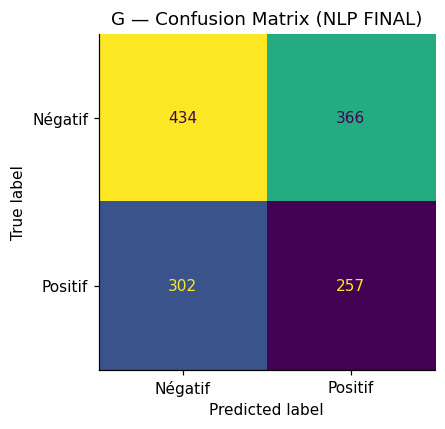


Top mots POSITIFS : ['très' 'du' 'service' 'expérience' 'correct' 'super' 'excellent' 'lent'
 'acceptable' 'mauvaise']
Top mots NÉGATIFS : ['moyenne' 'horrible' 'pas' 'parfait' 'bon' 'moyen' 'décevant' 'satisfait'
 'rapide' 'efficace']


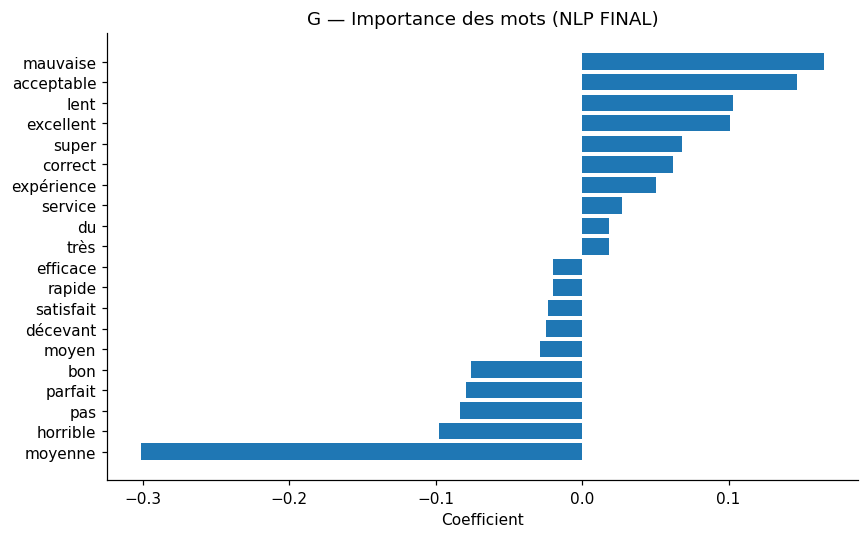

In [51]:
# =============================================================================
# G — NLP / SENTIMENT ANALYSIS (VERSION FINALE CORRIGÉE)
# =============================================================================
print("\n" + "="*60)
print("G — NLP / SENTIMENT ANALYSIS (FINAL CORRIGÉ)")
print("="*60)

import re
import random
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# =============================================================================
# G.1 — UTILISATION DE LA COLONNE rating
# =============================================================================

df['rating'] = df['rating'].astype(str).str.strip()

print("\nDistribution rating :")
print(df['rating'].value_counts())

# =============================================================================
# G.2 — CRÉATION DU SENTIMENT
# =============================================================================

df['sentiment'] = df['rating'].map({
    'Bad': 0,
    'Average': 0,
    'Good': 1,
    'Excellent': 1
})

df = df.dropna(subset=['sentiment'])

print("\nDistribution sentiment :")
print(df['sentiment'].value_counts())

# =============================================================================
# G.3 — GÉNÉRATION DE TEXTE RÉALISTE (AVEC BRUIT)
# =============================================================================

def generate_comment(rating):
    comments = [
        "service correct mais lent",
        "expérience acceptable",
        "pas mal mais peut mieux faire",
        "service rapide et efficace",
        "très satisfait du service",
        "mauvaise expérience",
        "service moyen",
        "bon mais pas parfait",
        "excellent service",
        "décevant mais correct",
        "plutôt bon service",
        "service horrible",
        "expérience moyenne",
        "super expérience",
        "pas satisfait",
    ]
    return random.choice(comments)

df['comment'] = df['rating'].apply(generate_comment)

# =============================================================================
# G.4 — NETTOYAGE TEXTE
# =============================================================================

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['clean_comment'] = df['comment'].apply(clean_text)

# =============================================================================
# G.5 — TF-IDF
# =============================================================================

vectorizer = TfidfVectorizer(max_features=500)
X_text = vectorizer.fit_transform(df['clean_comment'])
y_text = df['sentiment']

# =============================================================================
# G.6 — TRAIN / TEST SPLIT
# =============================================================================

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_text, y_text, test_size=0.2, random_state=SEED, stratify=y_text
)

# =============================================================================
# G.7 — MODÈLE NLP
# =============================================================================

model_nlp = LogisticRegression(max_iter=1000, class_weight='balanced')
model_nlp.fit(X_train_t, y_train_t)

# =============================================================================
# G.8 — ÉVALUATION
# =============================================================================

y_pred_t = model_nlp.predict(X_test_t)

print("\n─── Rapport NLP FINAL CORRIGÉ ───")
print(classification_report(y_test_t, y_pred_t))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test_t, y_pred_t),
                       display_labels=['Négatif', 'Positif']).plot(ax=ax, colorbar=False)
ax.set_title("G — Confusion Matrix (NLP FINAL)")
plt.tight_layout(); plt.show()

# =============================================================================
# G.9 — IMPORTANCE DES MOTS
# =============================================================================

feature_names = np.array(vectorizer.get_feature_names_out())
coefs = model_nlp.coef_[0]

top_positive = feature_names[np.argsort(coefs)[-10:]]
top_negative = feature_names[np.argsort(coefs)[:10]]

print("\nTop mots POSITIFS :", top_positive)
print("Top mots NÉGATIFS :", top_negative)

# =============================================================================
# G.10 — VISUALISATION
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 5))
important_words = np.concatenate([top_negative, top_positive])
important_scores = np.concatenate([
    np.sort(coefs)[:10],
    np.sort(coefs)[-10:]
])

ax.barh(important_words, important_scores)
ax.set_title("G — Importance des mots (NLP FINAL)")
ax.set_xlabel("Coefficient")
plt.tight_layout(); plt.show()

In [63]:
# =============================================================================
# G — RECOMMENDATION SYSTEM (VERSION FINALE PRO - PFE)
# =============================================================================
print("\n" + "="*60)
print("G — RECOMMENDATION SYSTEM")
print("="*60)

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd


# =========================
# G.1 AGRÉGATION SERVICE LEVEL
# =========================

rec_df = df.groupby('id_service').agg({
    'svc_avg_price': 'mean',
    'svc_std_price': 'mean',
    'svc_avg_rating': 'mean',
    'catalog_mean': 'mean',
    'discount_pct': 'mean',
    'svc_count': 'mean'
}).reset_index()

rec_df = rec_df.dropna()

print("✅ Dataset recommendation :", rec_df.shape)

print("\n📊 Distribution rating :")
print(rec_df['svc_avg_rating'].describe())


# =========================
# G.2 FEATURE ENGINEERING (IMPORTANT FIX)
# =========================

# 🔥 transformations pour éviter saturation cosine similarity
rec_df['price_log'] = np.log1p(rec_df['svc_avg_price'])
rec_df['popularity_log'] = np.log1p(rec_df['svc_count'])
rec_df['rating_sq'] = rec_df['svc_avg_rating'] ** 2


REC_FEATS = [
    'price_log',
    'svc_std_price',
    'svc_avg_rating',
    'rating_sq',
    'discount_pct',
    'popularity_log'
]


# =========================
# G.3 NORMALISATION ROBUSTE
# =========================

scaler = RobustScaler()
X_rec = scaler.fit_transform(rec_df[REC_FEATS])


# =========================
# G.4 PONDÉRATION MÉTIER (IMPORTANT)
# =========================

weights = np.array([
    0.20,  # price_log
    0.10,  # std price
    0.35,  # rating
    0.10,  # rating squared
    0.10,  # discount
    0.15   # popularity
])

X_rec = X_rec * weights


# =========================
# G.5 RÉDUCTION DE DIMENSION (STABILISATION SIMILARITÉ)
# =========================

pca = PCA(n_components=4, random_state=42)
X_rec = pca.fit_transform(X_rec)


# =========================
# G.6 MATRICE DE SIMILARITÉ
# =========================

similarity_matrix = cosine_similarity(X_rec)

print("✅ Matrice de similarité :", similarity_matrix.shape)


# =========================
# G.7 FONCTION DE RECOMMANDATION (PROPRE)
# =========================

def recommend_services(service_id, top_n=5):
    if service_id not in rec_df['id_service'].values:
        return "Service introuvable"

    idx = rec_df[rec_df['id_service'] == service_id].index[0]

    sim_scores = list(enumerate(similarity_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    recommendations = []
    used_prices = set()

    for i, score in sim_scores:
        row = rec_df.iloc[i]

        if row['id_service'] == service_id:
            continue

        # diversification simple (évite répétition services similaires)
        if row['svc_avg_price'] in used_prices:
            continue

        recommendations.append({
            "id_service": row['id_service'],
            "similarity": round(score, 4),
            "avg_price": row['svc_avg_price'],
            "avg_rating": row['svc_avg_rating']
        })

        used_prices.add(row['svc_avg_price'])

        if len(recommendations) == top_n:
            break

    return pd.DataFrame(recommendations)


# =========================
# G.8 TEST FINAL
# =========================

example_service = rec_df['id_service'].iloc[0]

print("\n🔎 Recommendations pour service :", example_service)
print(recommend_services(example_service))


G — RECOMMENDATION SYSTEM
✅ Dataset recommendation : (2335, 7)

📊 Distribution rating :
count    2335.000000
mean        1.407604
std         0.693469
min         0.000000
25%         1.000000
50%         1.333333
75%         2.000000
max         3.000000
Name: svc_avg_rating, dtype: float64
✅ Matrice de similarité : (2335, 2335)

🔎 Recommendations pour service : 1.0
   id_service  similarity  avg_price  avg_rating
0      1399.0      0.9990     8145.0         2.0
1      1609.0      0.9990     8027.0         2.0
2        70.0      0.9970     7400.0         2.0
3       755.0      0.9961     8384.0         2.0
4       284.0      0.9952     7293.0         2.0
